# Synthesis and Analysis of Suspensions and Exclusions Data
 
## Purpose and Overview
This notebook demonstrates how to generate, aggregate, and analyze synthetic data on suspensions and exclusions in England’s schools. The workflow covers data generation, aggregation at multiple geographic and educational levels, and calculation of key metrics for reporting and analysis.
 
## Table of Contents
- [Background](#background)
- [Generating the data](#generating-the-data)
    - [Summary of approach](#summary-of-approach)
    - [Step 1: Import Required Libraries](#step-1-import-required-libraries)
    - [Step 2: Set Up Parameters and Random Seed](#step-2-set-up-parameters-and-random-seed)
    - [Step 3: Generate Synthetic Data](#step-3-generate-synthetic-data-for-each-local-authority-and-education-phase)
    - [Step 4: Create DataFrame](#step-4-create-a-dataframe-from-the-generated-data)
    - [Step 5: Calculate Rates](#step-5-calculate-rates)
    - [Step 6: Create Breakdown Dictionary](#step-6-create-a-dictionary-for-different-breakdown-totals)
    - [Step 7: Aggregate and Calculate Rates by Group](#step-7-aggregating-totals-and-calculating-rates-by-group)
    - [Step 8: Save to CSV](#step-8-save-the-synthetic-data-to-csv)
 
## Background
This data is a time series about suspensions and exclusions in England, including the following breakdowns:
- National
- Regional
- Local authority
 
It also includes the following education phases:
- Primary
- Secondary
- Special
 
The data contains metrics for each breakdown:
- Headcounts: Number of pupils for the relevant breakdown
- Suspensions: Number of pupils suspended
- Exclusions: Number of pupils excluded
- Suspension rate: Suspensions divided by headcounts
- Exclusion rate: Exclusions divided by headcounts
 
## Generating the Data

### Summary of Approach: 

- Data generation is made reproducible by setting a random seed.
- Synthetic data is generated at the local authority level for different time periods and education phases.
- Headcounts, suspensions, and exclusions are generated using realistic statistical distributions and clipped to avoid unrealistic values.
- Aggregation is performed to calculate totals and rates at regional and national levels.

### Step 1: Import Required Libraries
We import pandas for data manipulation and numpy for generating random numbers. These libraries provide efficient tools for handling, analyzing, and generating synthetic data.

In [56]:
import pandas as pd
import numpy as np

### Step 2: Set Up Parameters and Random Seed
We set a random seed using numpy to ensure that the synthetic data generation is reproducible. This is important for consistent analysis and debugging. We also define single-value parameters (such as time identifier and country information) that will be used throughout the data generation process.

In [57]:
# Set random seed for reproducibility
np.random.seed(42)

#set up single value parameters 

#create a time identifier vairable
time_identifier = "Autumn Term"

# define geographic level
geographic_levels = "Local Authority"

#create country_code

country_code = "E92000001"

#create country name 

country_name = "England"

Now we set up multi-value parameters using lists and dictionaries. These include time periods, education phases, and local authority/region codes, which define the structure and breakdowns of the synthetic dataset.

In [58]:
#set up multi value parameters 
# create a time period variable

time_period = ["201819","201920","202021","202122","202223","202324","202425"]

#create region_code dictionary 

region_dict = {
    "E12000001": "North East",
    "E12000002": "North West",
    "E12000003": "Yorkshire and The Humber",
    "E12000004": "East Midlands",
    "E12000005": "West Midlands",
    "E12000006": "East of England",
    "E12000007": "London",
    "E12000008": "South East",
    "E12000009": "South West",
    "E13000001": "Inner London",
    "E13000002": "Outer London"
}


#create la_code dictionary

la_dict = {
    "E06000001": {"name": "Hartlepool", "parent_geography_code": "E12000001"},
    "E06000002": {"name": "Middlesbrough", "parent_geography_code": "E12000001"},
    "E06000003": {"name": "Redcar and Cleveland", "parent_geography_code": "E12000001"},
    "E06000004": {"name": "Stockton-on-Tees", "parent_geography_code": "E12000001"},
    "E06000005": {"name": "Darlington", "parent_geography_code": "E12000001"},
    "E06000006": {"name": "Halton", "parent_geography_code": "E12000002"},
    "E06000007": {"name": "Warrington", "parent_geography_code": "E12000002"},
    "E06000008": {"name": "Blackburn with Darwen", "parent_geography_code": "E12000002"},
    "E06000009": {"name": "Blackpool", "parent_geography_code": "E12000002"},
    "E06000010": {"name": "Kingston upon Hull, City of", "parent_geography_code": "E12000003"},
    "E06000011": {"name": "East Riding of Yorkshire", "parent_geography_code": "E12000003"},
    "E06000012": {"name": "North East Lincolnshire", "parent_geography_code": "E12000003"},
    "E06000013": {"name": "North Lincolnshire", "parent_geography_code": "E12000003"},
    "E06000014": {"name": "York", "parent_geography_code": "E12000003"},
    "E06000015": {"name": "Derby", "parent_geography_code": "E12000004"},
    "E06000016": {"name": "Leicester", "parent_geography_code": "E12000004"},
    "E06000017": {"name": "Rutland", "parent_geography_code": "E12000004"},
    "E06000018": {"name": "Nottingham", "parent_geography_code": "E12000004"},
    "E06000019": {"name": "Herefordshire, County of", "parent_geography_code": "E12000005"},
    "E06000020": {"name": "Telford and Wrekin", "parent_geography_code": "E12000005"},
    "E06000021": {"name": "Stoke-on-Trent", "parent_geography_code": "E12000005"},
    "E06000022": {"name": "Bath and North East Somerset", "parent_geography_code": "E12000009"},
    "E06000023": {"name": "Bristol, City of", "parent_geography_code": "E12000009"},
    "E06000024": {"name": "North Somerset", "parent_geography_code": "E12000009"},
    "E06000025": {"name": "South Gloucestershire", "parent_geography_code": "E12000009"},
    "E06000026": {"name": "Plymouth", "parent_geography_code": "E12000009"},
    "E06000027": {"name": "Torbay", "parent_geography_code": "E12000009"},
    "E06000028": {"name": "Bournemouth", "parent_geography_code": "E12000009"},
    "E06000029": {"name": "Poole", "parent_geography_code": "E12000009"},
    "E06000030": {"name": "Swindon", "parent_geography_code": "E12000009"},
    "E06000031": {"name": "Peterborough", "parent_geography_code": "E12000006"},
    "E06000032": {"name": "Luton", "parent_geography_code": "E12000006"},
    "E06000033": {"name": "Southend-on-Sea", "parent_geography_code": "E12000006"},
    "E06000034": {"name": "Thurrock", "parent_geography_code": "E12000006"},
    "E06000035": {"name": "Medway", "parent_geography_code": "E12000008"},
    "E06000036": {"name": "Bracknell Forest", "parent_geography_code": "E12000008"},
    "E06000037": {"name": "West Berkshire", "parent_geography_code": "E12000008"},
    "E06000038": {"name": "Reading", "parent_geography_code": "E12000008"},
    "E06000039": {"name": "Slough", "parent_geography_code": "E12000008"},
    "E06000040": {"name": "Windsor and Maidenhead", "parent_geography_code": "E12000008"},
    "E06000041": {"name": "Wokingham", "parent_geography_code": "E12000008"},
    "E06000042": {"name": "Milton Keynes", "parent_geography_code": "E12000008"},
    "E06000043": {"name": "Brighton and Hove", "parent_geography_code": "E12000008"},
    "E06000044": {"name": "Portsmouth", "parent_geography_code": "E12000008"},
    "E06000045": {"name": "Southampton", "parent_geography_code": "E12000008"},
    "E06000046": {"name": "Isle of Wight", "parent_geography_code": "E12000008"},
    "E06000047": {"name": "County Durham", "parent_geography_code": "E12000001"},
    "E06000048": {"name": "Northumberland", "parent_geography_code": "E12000001"},
    "E06000049": {"name": "Cheshire East", "parent_geography_code": "E12000002"},
    "E06000050": {"name": "Cheshire West and Chester", "parent_geography_code": "E12000002"},
    "E06000051": {"name": "Shropshire", "parent_geography_code": "E12000005"},
    "E06000052": {"name": "Cornwall", "parent_geography_code": "E12000009"},
    "E06000053": {"name": "Isles of Scilly", "parent_geography_code": "E12000009"},
    "E06000054": {"name": "Wiltshire", "parent_geography_code": "E12000009"},
    "E06000055": {"name": "Bedford", "parent_geography_code": "E12000006"},
    "E06000056": {"name": "Central Bedfordshire", "parent_geography_code": "E12000006"},
    "E06000057": {"name": "Northumberland", "parent_geography_code": "E12000001"},
    "E06000058": {"name": "Bournemouth, Christchurch and Poole", "parent_geography_code": "E12000009"},
    "E06000059": {"name": "Dorset", "parent_geography_code": "E12000009"},
    "E06000060": {"name": "Buckinghamshire", "parent_geography_code": "E12000008"},
    "E06000061": {"name": "North Northamptonshire", "parent_geography_code": "E12000004"},
    "E06000062": {"name": "West Northamptonshire", "parent_geography_code": "E12000004"},
    "E06000063": {"name": "Cumberland", "parent_geography_code": "E12000002"},
    "E06000064": {"name": "Westmorland and Furness", "parent_geography_code": "E12000002"},
    "E06000065": {"name": "North Yorkshire", "parent_geography_code": "E12000003"},
    "E06000066": {"name": "Somerset", "parent_geography_code": "E12000009"},
    "E08000001": {"name": "Bolton", "parent_geography_code": "E12000002"},
    "E08000002": {"name": "Bury", "parent_geography_code": "E12000002"},
    "E08000003": {"name": "Manchester", "parent_geography_code": "E12000002"},
    "E08000004": {"name": "Oldham", "parent_geography_code": "E12000002"},
    "E08000005": {"name": "Rochdale", "parent_geography_code": "E12000002"},
    "E08000006": {"name": "Salford", "parent_geography_code": "E12000002"},
    "E08000007": {"name": "Stockport", "parent_geography_code": "E12000002"},
    "E08000008": {"name": "Tameside", "parent_geography_code": "E12000002"},
    "E08000009": {"name": "Trafford", "parent_geography_code": "E12000002"},
    "E08000010": {"name": "Wigan", "parent_geography_code": "E12000002"},
    "E08000011": {"name": "Knowsley", "parent_geography_code": "E12000002"},
    "E08000012": {"name": "Liverpool", "parent_geography_code": "E12000002"},
    "E08000013": {"name": "St. Helens", "parent_geography_code": "E12000002"},
    "E08000014": {"name": "Sefton", "parent_geography_code": "E12000002"},
    "E08000015": {"name": "Wirral", "parent_geography_code": "E12000002"},
    "E08000016": {"name": "Barnsley", "parent_geography_code": "E12000003"},
    "E08000017": {"name": "Doncaster", "parent_geography_code": "E12000003"},
    "E08000018": {"name": "Rotherham", "parent_geography_code": "E12000003"},
    "E08000019": {"name": "Sheffield", "parent_geography_code": "E12000003"},
    "E08000020": {"name": "Gateshead", "parent_geography_code": "E12000001"},
    "E08000021": {"name": "Newcastle upon Tyne", "parent_geography_code": "E12000001"},
    "E08000022": {"name": "North Tyneside", "parent_geography_code": "E12000001"},
    "E08000023": {"name": "South Tyneside", "parent_geography_code": "E12000001"},
    "E08000024": {"name": "Sunderland", "parent_geography_code": "E12000001"},
    "E08000025": {"name": "Birmingham", "parent_geography_code": "E12000005"},
    "E08000026": {"name": "Coventry", "parent_geography_code": "E12000005"},
    "E08000027": {"name": "Dudley", "parent_geography_code": "E12000005"},
    "E08000028": {"name": "Sandwell", "parent_geography_code": "E12000005"},
    "E08000029": {"name": "Solihull", "parent_geography_code": "E12000005"},
    "E08000030": {"name": "Walsall", "parent_geography_code": "E12000005"},
    "E08000031": {"name": "Wolverhampton", "parent_geography_code": "E12000005"},
    "E08000032": {"name": "Bradford", "parent_geography_code": "E12000003"},
    "E08000033": {"name": "Calderdale", "parent_geography_code": "E12000003"},
    "E08000034": {"name": "Kirklees", "parent_geography_code": "E12000003"},
    "E08000035": {"name": "Leeds", "parent_geography_code": "E12000003"},
    "E08000036": {"name": "Wakefield", "parent_geography_code": "E12000003"},
    "E08000037": {"name": "Gateshead", "parent_geography_code": "E12000001"},
    "E08000038": {"name": "Barnsley", "parent_geography_code": "E12000003"},
    "E08000039": {"name": "Sheffield", "parent_geography_code": "E12000003"},
    "E09000001": {"name": "City of London", "parent_geography_code": "E12000007"},
    "E09000002": {"name": "Barking and Dagenham", "parent_geography_code": "E12000007"},
    "E09000003": {"name": "Barnet", "parent_geography_code": "E12000007"},
    "E09000004": {"name": "Bexley", "parent_geography_code": "E12000007"},
    "E09000005": {"name": "Brent", "parent_geography_code": "E12000007"},
    "E09000006": {"name": "Bromley", "parent_geography_code": "E12000007"},
    "E09000007": {"name": "Camden", "parent_geography_code": "E12000007"},
    "E09000008": {"name": "Croydon", "parent_geography_code": "E12000007"},
    "E09000009": {"name": "Ealing", "parent_geography_code": "E12000007"},
    "E09000010": {"name": "Enfield", "parent_geography_code": "E12000007"},
    "E09000011": {"name": "Greenwich", "parent_geography_code": "E12000007"},
    "E09000012": {"name": "Hackney", "parent_geography_code": "E12000007"},
    "E09000013": {"name": "Hammersmith and Fulham", "parent_geography_code": "E12000007"},
    "E09000014": {"name": "Haringey", "parent_geography_code": "E12000007"},
    "E09000015": {"name": "Harrow", "parent_geography_code": "E12000007"},
    "E09000016": {"name": "Havering", "parent_geography_code": "E12000007"},
    "E09000017": {"name": "Hillingdon", "parent_geography_code": "E12000007"},
    "E09000018": {"name": "Hounslow", "parent_geography_code": "E12000007"},
    "E09000019": {"name": "Islington", "parent_geography_code": "E12000007"},
    "E09000020": {"name": "Kensington and Chelsea", "parent_geography_code": "E12000007"},
    "E09000021": {"name": "Kingston upon Thames", "parent_geography_code": "E12000007"},
    "E09000022": {"name": "Lambeth", "parent_geography_code": "E12000007"},
    "E09000023": {"name": "Lewisham", "parent_geography_code": "E12000007"},
    "E09000024": {"name": "Merton", "parent_geography_code": "E12000007"},
    "E09000025": {"name": "Newham", "parent_geography_code": "E12000007"},
    "E09000026": {"name": "Redbridge", "parent_geography_code": "E12000007"},
    "E09000027": {"name": "Richmond upon Thames", "parent_geography_code": "E12000007"},
    "E09000028": {"name": "Southwark", "parent_geography_code": "E12000007"},
    "E09000029": {"name": "Sutton", "parent_geography_code": "E12000007"},
    "E09000030": {"name": "Tower Hamlets", "parent_geography_code": "E12000007"},
    "E09000031": {"name": "Waltham Forest", "parent_geography_code": "E12000007"},
    "E09000032": {"name": "Wandsworth", "parent_geography_code": "E12000007"},
    "E09000033": {"name": "Westminster", "parent_geography_code": "E12000007"},
    "E10000001": {"name": "Bedfordshire", "parent_geography_code": "E12000006"},
    "E10000002": {"name": "Buckinghamshire", "parent_geography_code": "E12000008"},
    "E10000003": {"name": "Cambridgeshire", "parent_geography_code": "E12000006"},
    "E10000004": {"name": "Cheshire", "parent_geography_code": "E12000002"},
    "E10000005": {"name": "Cornwall and Isles of Scilly", "parent_geography_code": "E12000009"},
    "E10000006": {"name": "Cumbria", "parent_geography_code": "E12000002"},
    "E10000007": {"name": "Derbyshire", "parent_geography_code": "E12000004"},
    "E10000008": {"name": "Devon", "parent_geography_code": "E12000009"},
    "E10000009": {"name": "Dorset", "parent_geography_code": "E12000009"},
    "E10000010": {"name": "Durham", "parent_geography_code": "E12000001"},
    "E10000011": {"name": "East Sussex", "parent_geography_code": "E12000008"},
    "E10000012": {"name": "Essex", "parent_geography_code": "E12000006"},
    "E10000013": {"name": "Gloucestershire", "parent_geography_code": "E12000009"},
    "E10000014": {"name": "Hampshire", "parent_geography_code": "E12000008"},
    "E10000015": {"name": "Hertfordshire", "parent_geography_code": "E12000006"},
    "E10000016": {"name": "Kent", "parent_geography_code": "E12000008"},
    "E10000017": {"name": "Lancashire", "parent_geography_code": "E12000002"},
    "E10000018": {"name": "Leicestershire", "parent_geography_code": "E12000004"},
    "E10000019": {"name": "Lincolnshire", "parent_geography_code": "E12000004"},
    "E10000020": {"name": "Norfolk", "parent_geography_code": "E12000006"},
    "E10000021": {"name": "Northamptonshire", "parent_geography_code": "E12000004"},
    "E10000022": {"name": "Northumberland", "parent_geography_code": "E12000001"},
    "E10000023": {"name": "North Yorkshire", "parent_geography_code": "E12000003"},
    "E10000024": {"name": "Nottinghamshire", "parent_geography_code": "E12000004"},
    "E10000025": {"name": "Oxfordshire", "parent_geography_code": "E12000008"},
    "E10000026": {"name": "Shropshire", "parent_geography_code": "E12000005"},
    "E10000027": {"name": "Somerset", "parent_geography_code": "E12000009"},
    "E10000028": {"name": "Staffordshire", "parent_geography_code": "E12000005"},
    "E10000029": {"name": "Suffolk", "parent_geography_code": "E12000006"},
    "E10000030": {"name": "Surrey", "parent_geography_code": "E12000008"},
    "E10000031": {"name": "Warwickshire", "parent_geography_code": "E12000005"},
    "E10000032": {"name": "West Sussex", "parent_geography_code": "E12000008"},
    "E10000033": {"name": "Wiltshire", "parent_geography_code": "E12000009"},
    "E10000034": {"name": "Worcestershire", "parent_geography_code": "E12000005"},
}



#define education phases

education_phases = ["Primary", "Secondary", "Special"]

### Step 3: Generate Synthetic Data for Each Local Authority and Education Phase
We loop through all combinations of time periods, local authorities, and education phases to generate synthetic data. For each combination:
- Headcounts are generated using a log-normal distribution to simulate realistic pupil numbers.
- Suspensions are generated using a negative binomial distribution, ensuring the value is always less than the headcount.
- Exclusions are generated using a Poisson distribution, also clipped to be less than the headcount.
- All values are clipped to avoid unrealistic results (e.g., negative or excessively large numbers).
This approach ensures the dataset mimics real-world patterns and constraints.

In [59]:
#create an empty list
main_data=[]

# create a for loop over time periods and local authority data to generate data for all 
# local authorities and time periods to create time series data

for time_period in time_period:
    for la_code, la_info in la_dict.items():
                # get the parent region code for this LA
                parent_region_code = la_info["parent_geography_code"]
                # get the LA name
                la_name = la_info["name"]
                # get the region name from the region dictionary
                region_name = region_dict[parent_region_code]
                # for each education phase
                for phase in education_phases: 
                    # create log normally distributed head counts for LA
                    headcount = int(np.clip(np.random.lognormal(1e3, 4e3), 1e2, 3e4))
                    #create suspension numbers to append later - negative binomially distributed
                    suspensions = int(np.clip(np.random.negative_binomial(50, 0.05), 0, min(1000, headcount-1)))
                    #create exclusions numbers to append later - Poisson distributed
                    exclusions = int(np.clip(np.random.poisson(20), 0, headcount-1))
                    # append the data for this LA and phase
                    main_data.append({
                        # put the time identifer as is
                        "time_identifier": time_identifier,
                        # put the time period as is
                        "time_period": time_period,
                        # use each geographic level
                        "geographic_level": geographic_levels, 
                        # use country code as is because it's the same throughout 
                        "country_code": country_code,
                        # use country name as is because it's the same throughout 
                        "country_name": country_name, 
                        # use the parent region code for this LA
                        "region_code": parent_region_code, 
                        # use the region name for this LA
                        "region_name": region_name, 
                        # use the LA code for this row
                        "la_code": la_code,
                        # use the LA name for this row
                        "la_name": la_name, 
                        # use each education phase
                        "education_phases": phase,
                        # use the headcount data generated earlier 
                        "headcount": headcount,
                        #append suspensions 
                        "suspensions": suspensions,
                        #append exclusions
                        "exclusions": exclusions
                    })


### Step 4: Create a DataFrame from the generated data

Now we will put the list of data we created from the for loop into a dataframe to carry out calculations. We will follow that by using the `head()` function to check the first few rows of data to see what they look like. 

In [60]:
# convert the list of data into a dataframe 

df = pd.DataFrame(main_data)
#check what the data looks like by viewing the first 5 rows
df.head()

,time_identifier,time_period,geographic_level,country_code,country_name,region_code,region_name,la_code,la_name,education_phases,headcount,suspensions,exclusions
0,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Primary,30000,934,15
1,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Secondary,30000,1000,15
2,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Special,30000,693,14
3,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Primary,100,99,21
4,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Secondary,100,99,13


### Step 5: Calculate rates

Now we will calculate the rates for suspensions and exclusions by dividing those metrics by the corresponding headcounts for each local authority and region. We will also add a line to replace any NA values with 0. This is not really needed in this code because we know there are no missing values as we generated the data for each level but it's good practice to ensure that there is code to deal with missing values. 

In [61]:


#calculate suspension and exclusion rate for the la data we created

df["susp_rate"] = df["suspensions"]/df["headcount"]
#fill na with 0
df["susp_rate"] = df["susp_rate"].fillna(0)
# do exclusion rate for the la data we created
df["excl_rate"] = df["exclusions"]/df["headcount"]
# fill na with 0
df["excl_rate"] = df["excl_rate"].fillna(0)

#check what the data looks like

df.head()

,time_identifier,time_period,geographic_level,country_code,country_name,region_code,region_name,la_code,la_name,education_phases,headcount,suspensions,exclusions,susp_rate,excl_rate
0,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Primary,30000,934,15,0.031133,0.000500
1,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Secondary,30000,1000,15,0.033333,0.000500
2,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000001,Hartlepool,Special,30000,693,14,0.023100,0.000467
3,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Primary,100,99,21,0.990000,0.210000
4,Autumn Term,201819,Local Authority,E92000001,England,E12000001,North East,E06000002,Middlesbrough,Secondary,100,99,13,0.990000,0.130000


### Step 6: Create a dictionary for different breakdown totals

In my organisation, we publish data for different breakdowns that take different groups into account. We will use the local authority data to calculate those breakdowns. 

First, we will create a dictionary and define the different groups we want our breakdowns to be about. For example, we have the regional_edu breakdown and that will get regional totaly bu education phases for each time period.

We will then create a list that contains the df we generated in an earlier step and this will be used in a for loop that we will create that will use this dictionary. 

In [62]:
#create a dictionary of the list of groups i want to create 
total_groups_name= {"la":["time_period","la_code","la_name", "region_code", "region_name"], # get la totals for education phase
                    "regional_edu":["time_period","education_phases", "region_code", "region_name"], # get regional totals by education phase 
                    "regional_overall":["time_period","region_code", "region_name"], # get regional totals for the education phases
                    "national_edu":["time_period","education_phases"], #get national totals for phases
                    "national_overall":["time_period","country_name"]} #  get overall national totals



#start a list with the data frame we created of LAs earlier
mylist=[df]

### Step 7 - Aggregating Totals and Calculating Rates by Group

This code iterates over a dictionary of groupings to calculate summary statistics for different breakdowns of the data (e.g., by local authority, region, or nationally). For each grouping:

- The data is grouped and summed for headcounts, suspensions, and exclusions.
- Suspension and exclusion rates are calculated by dividing the respective counts by headcounts, with missing values filled as zero.
- Additional columns are assigned to indicate the time period, country, and the appropriate geographic level (local, regional, or national).
- If a grouping does not include education phase, it is labeled as "Total" for that column.
- Each resulting summary DataFrame is appended to a list for later use or concatenation.

This approach ensures that all required breakdowns and rates are calculated in a systematic and reproducible way.

In [63]:
#use a for loop to get totals for headcounts, suspensions and suspension rates for different categories 

# for each type of group and col name specified in the dictionary 
for group_name, group_cols in total_groups_name.items():
        # do a groupby sum using the cols in the dict
        sub_total_df = df.groupby(group_cols, as_index=False)[["headcount", "suspensions","exclusions"]].sum()
        #calculate suspension rate
        sub_total_df["susp_rate"]  = sub_total_df["suspensions"]/sub_total_df["headcount"]
        # fill na with 0
        sub_total_df["susp_rate"] = sub_total_df["susp_rate"].fillna(0)
        # calculate exclusion rate
        sub_total_df["excl_rate"]  = sub_total_df["exclusions"]/sub_total_df["headcount"]
        # fill na with 0
        sub_total_df["excl_rate"] = sub_total_df["excl_rate"].fillna(0)
        #assign variables
        sub_total_df["time_identifier"]= time_identifier
        #sub_total_df["time_period"]= time_period
        sub_total_df["country_code"]= country_code
        sub_total_df["country_name"]= country_name

        # if the education phase isn't in the columns in the groupby, then assign it as "Total"
        if "education_phases" not in group_cols:
            sub_total_df["education_phases"] = "Total"
        # if the group name is la then assign the values below
        if group_name == "la":
              sub_total_df["geographic_level"] = geographic_levels
              sub_total_df["education_phases"]= "Total"
        #if they're regional_overall or regional_edu then assign geographic_level as regional 
        elif group_name== "regional_overall" or group_name == "regional_edu":
            sub_total_df["geographic_level"]= "Regional"
        
        #if they're national_overall or national_edu then assign geographic_level as national 
        elif group_name == "national_edu" or group_name == "national_overall":
            sub_total_df["geographic_level"]= "National"


        #append the data to the list 
        mylist.append(sub_total_df)

### Step 6: Save the synthetic data to CSV

In [64]:
# we concat the list of dataframes together aka bind them
df = pd.concat(mylist)
#we export it to csv
df.to_csv("susp_exc_fake_data.csv", index = False)


## Exploratory data analysis

We will use this section to explore the data we created in more detail.

### Step 1 - Import neccessary packages 


In [81]:
import matplotlib.pyplot as plt
import seaborn as sb


### Step 2 - read in the csv data and explore its different attributes

We will use various functions to explore the dataset. We will use the following functions: 

-   head - to view the first few rows of the data 
-   shape - to understand the number of rows and columns in the data and get an idea of its size and structure.
-   info - to see the number of records, the type of data and whether there is missing data in each column.
-   describe - to get a statistical summary of the data frame showing measures like count, mean, standard deviation, etc. 



In [66]:
# view the first few rows

susp_exc= pd.read_csv("susp_exc_fake_data.csv")

# show the first few rows 

print(susp_exc.head())

  time_identifier  time_period geographic_level country_code country_name  \
0     Autumn Term       201819  Local Authority    E92000001      England   
1     Autumn Term       201819  Local Authority    E92000001      England   
2     Autumn Term       201819  Local Authority    E92000001      England   
3     Autumn Term       201819  Local Authority    E92000001      England   
4     Autumn Term       201819  Local Authority    E92000001      England   

  region_code region_name    la_code        la_name education_phases  \
0   E12000001  North East  E06000001     Hartlepool          Primary   
1   E12000001  North East  E06000001     Hartlepool        Secondary   
2   E12000001  North East  E06000001     Hartlepool          Special   
3   E12000001  North East  E06000002  Middlesbrough          Primary   
4   E12000001  North East  E06000002  Middlesbrough        Secondary   

   headcount  suspensions  exclusions  susp_rate  excl_rate  
0      30000          934          15   0.

In [67]:
#get the shape of the data
susp_exc.shape

(5096, 15)

In [68]:
#get info about the different rows and cols
susp_exc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5096 entries, 0 to 5095
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   time_identifier   5096 non-null   object 
 1   time_period       5096 non-null   int64  
 2   geographic_level  5096 non-null   object 
 3   country_code      5096 non-null   object 
 4   country_name      5096 non-null   object 
 5   region_code       5068 non-null   object 
 6   region_name       5068 non-null   object 
 7   la_code           4816 non-null   object 
 8   la_name           4816 non-null   object 
 9   education_phases  5096 non-null   object 
 10  headcount         5096 non-null   int64  
 11  suspensions       5096 non-null   int64  
 12  exclusions        5096 non-null   int64  
 13  susp_rate         5096 non-null   float64
 14  excl_rate         5096 non-null   float64
dtypes: float64(2), int64(4), object(9)
memory usage: 597.3+ KB


In [69]:
#get a stats summary about the data 
susp_exc.describe()

,time_period,headcount,suspensions,exclusions,susp_rate,excl_rate
count,5096.000000,5.096000e+03,5096.000000,5096.000000,5096.000000,5096.000000
mean,202122.000000,7.643089e+04,2490.615777,85.205651,0.318696,0.060487
std,202.019822,4.163595e+05,13555.041163,462.634010,0.439154,0.094292
min,201819.000000,1.000000e+02,99.000000,6.000000,0.017433,0.000200
25%,201920.000000,1.000000e+02,99.000000,18.000000,0.030767,0.000667
50%,202122.000000,3.000000e+04,928.000000,22.000000,0.033333,0.000962
75%,202324.000000,3.020000e+04,1088.500000,53.000000,0.990000,0.160000
max,202425.000000,9.918600e+06,317829.000000,10429.000000,0.990000,0.370000


### Step 3 - Univariate analysis and visuals

In this step, we will create charts to help us visualise and understand patterns for each variable in the data. This type of analysis is known as univariate analysis. 

First we will explore the headcounts, suspensions and exclusions vairables through a boxplot. This will help us explore the following componenets: 

-   Median: The middle value of the data, shown as a line inside the box.
-   Box: The box shows where the middle 50% of the data sits (between the lower quartile, Q1, and upper quartile, Q3).
-   Whiskers: Lines that stretch from the box to the smallest and largest values, except for any outliers.
-   Outliers: Dots or points outside the whiskers that are much higher or lower than most of the data.
-   Caps: Short lines at the ends of the whiskers, marking the minimum and maximum values (including outliers).



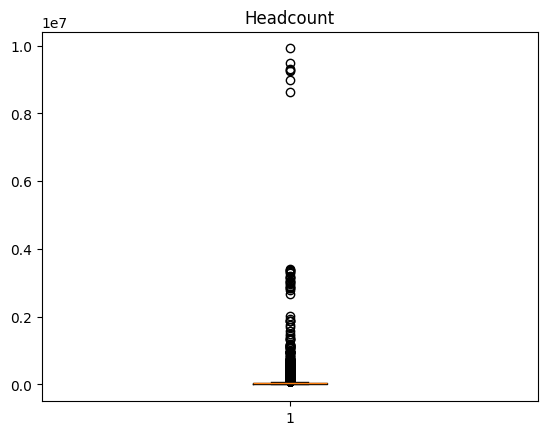

In [70]:
plt.boxplot(susp_exc["headcount"])
plt.title("Headcount")
plt.show()

That chart was not as useful because it contains muliple breakdowns so we need to filter the data first before we plot it. 

In [71]:
# Filter for rows where education_phases is 'Total' and geographic_level is 'National' to get the totals
filtered = susp_exc[(susp_exc["education_phases"] == "Total") & (susp_exc["geographic_level"] == "National")]
filtered.head()

,time_identifier,time_period,geographic_level,country_code,country_name,region_code,region_name,la_code,la_name,education_phases,headcount,suspensions,exclusions,susp_rate,excl_rate
5089,Autumn Term,201819,National,E92000001,England,NaN,NaN,NaN,NaN,Total,9260800,302183,10249,0.032630,0.001107
5090,Autumn Term,201920,National,E92000001,England,NaN,NaN,NaN,NaN,Total,8991700,295589,10296,0.032874,0.001145
5091,Autumn Term,202021,National,E92000001,England,NaN,NaN,NaN,NaN,Total,9918600,317829,10311,0.032044,0.001040
5092,Autumn Term,202122,National,E92000001,England,NaN,NaN,NaN,NaN,Total,9500000,309606,10427,0.032590,0.001098
5093,Autumn Term,202223,National,E92000001,England,NaN,NaN,NaN,NaN,Total,9290700,302876,10429,0.032600,0.001123


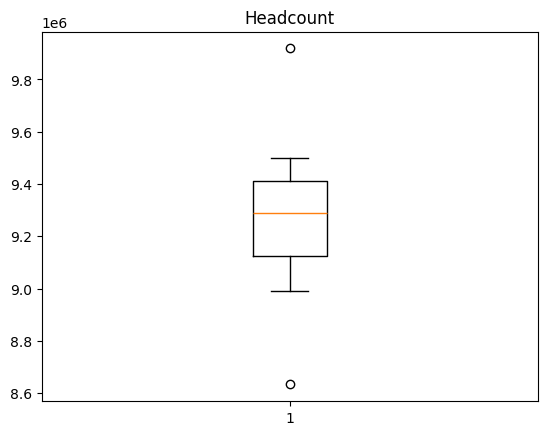

In [72]:
#create a boxplot for headcounts only
plt.boxplot(filtered["headcount"])
plt.title("Headcount")
plt.show()

Now let's create one for each metric nationally. 

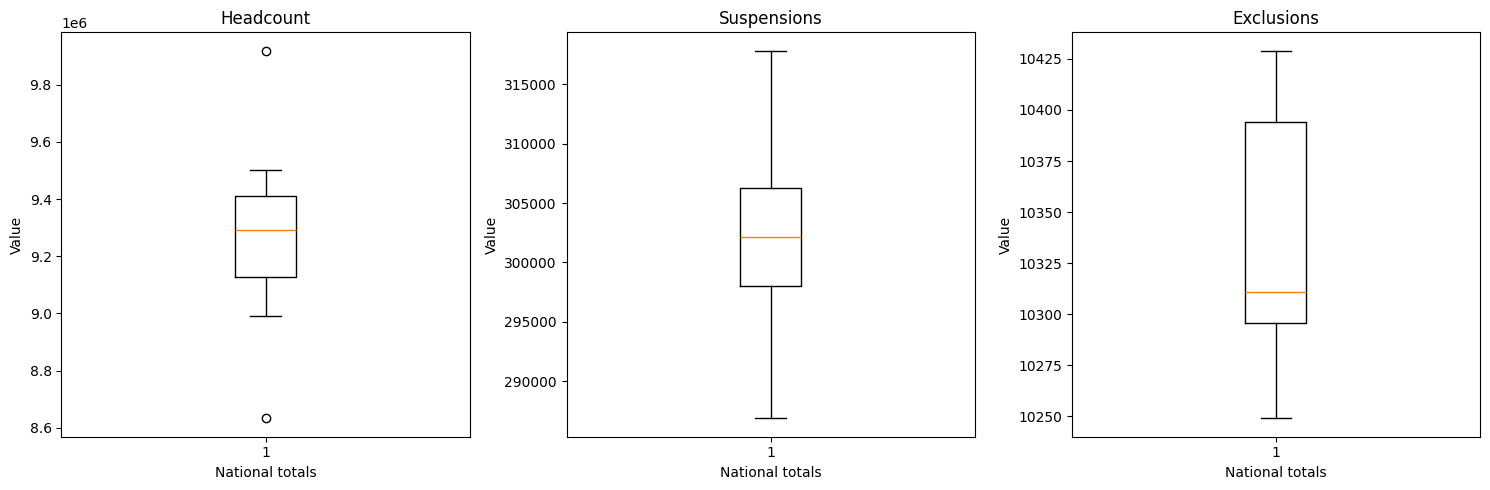

In [73]:
#create subplots 
fig, axs = plt.subplots(1,3,figsize=(15,5))

# do the plot for headcounts 

axs[0].boxplot(filtered["headcount"])
axs[0].set_title("Headcount")
axs[0].set_xlabel("National totals")
axs[0].set_ylabel("Value")

# do the plot for suspensions

axs[1].boxplot(filtered["suspensions"])
axs[1].set_title("Suspensions")
axs[1].set_xlabel("National totals")
axs[1].set_ylabel("Value")

# do the plot for headcounts 

axs[2].boxplot(filtered["exclusions"])
axs[2].set_title("Exclusions")
axs[2].set_xlabel("National totals")
axs[2].set_ylabel("Value")


plt.tight_layout()

plt.show()



Now let's explore the rates in a similar way.

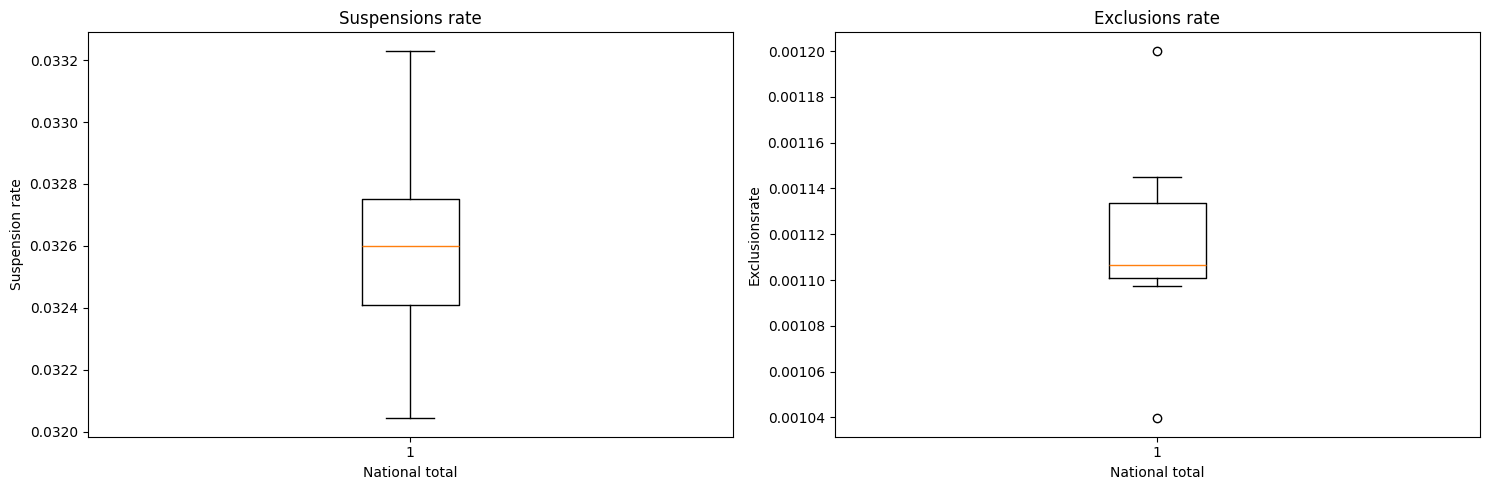

In [74]:
#set up the subplots 
fig, axs = plt.subplots(1,2, figsize=(15,5))
# create the plot for suspensions rate
axs[0].boxplot(filtered["susp_rate"])
axs[0].set_title("Suspensions rate")
axs[0].set_ylabel("Suspension rate")
axs[0].set_xlabel("National total")
#create the plot for rate of exclusions 
axs[1].boxplot(filtered["excl_rate"])
axs[1].set_title("Exclusions rate")
axs[1].set_ylabel("Exclusionsrate")
axs[1].set_xlabel("National total")

plt.tight_layout()
plt.show()

Now we will explore bar charts.

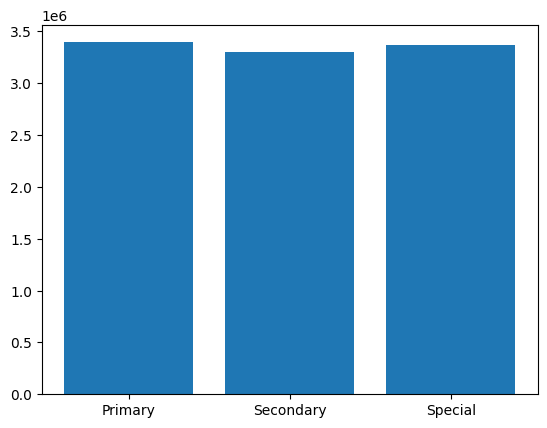

In [75]:
filtered = susp_exc[(susp_exc["geographic_level"]=="National") & (susp_exc["education_phases"]!= "Total")]
plt.bar(filtered["education_phases"], filtered["headcount"])
plt.show()

In [86]:
# Filter for regional totals (education_phases == 'Total')
filtered = susp_exc[(susp_exc["geographic_level"]=="National") & (susp_exc["education_phases"]!="Total")]
# Pivot the data longer for rates

long_df = pd.melt(filtered, 
                  id_vars=["education_phases", "time_period", "geographic_level", "time_identifier", "country_code", "country_name"],
                  value_vars=["susp_rate", "excl_rate"],
                  var_name="metric", value_name="rate")
long_df.head()

,education_phases,time_period,geographic_level,time_identifier,country_code,country_name,metric,rate
0,Primary,201819,National,Autumn Term,E92000001,England,susp_rate,0.032000
1,Secondary,201819,National,Autumn Term,E92000001,England,susp_rate,0.033264
2,Special,201819,National,Autumn Term,E92000001,England,susp_rate,0.032732
3,Primary,201920,National,Autumn Term,E92000001,England,susp_rate,0.032383
4,Secondary,201920,National,Autumn Term,E92000001,England,susp_rate,0.033822


<Axes: xlabel='education_phases', ylabel='rate'>

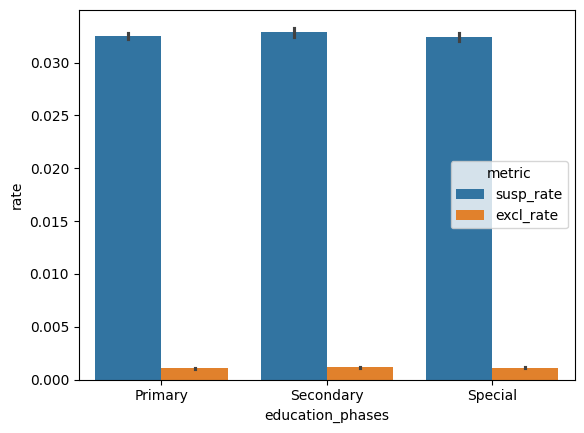

In [87]:
sb.barplot(x="education_phases",
           y = "rate",
           hue = "metric",
           data = long_df)